In [10]:
import pandas as pd

df = pd.read_csv("../data/nassau_dataset.csv")

print(df.head())
print(df.info())

   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1       60540  Chocola

In [12]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [14]:
df["Lead_Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [5]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


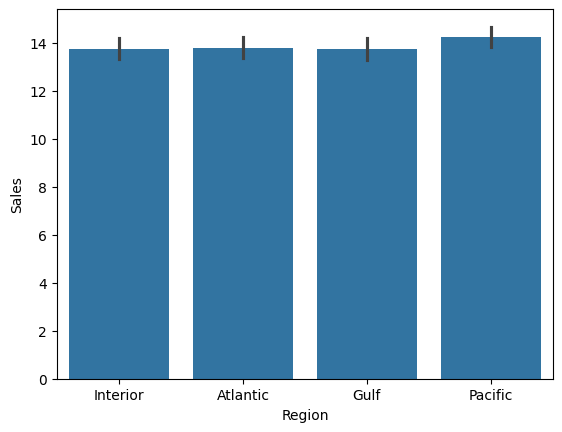

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x="Region", y="Sales")
plt.show()

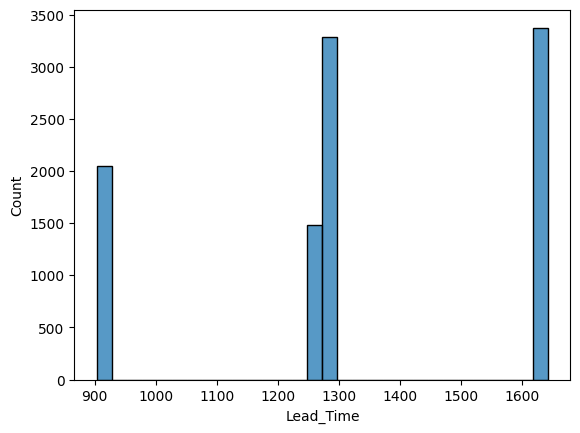

In [15]:
sns.histplot(df["Lead_Time"], bins=30)
plt.show()

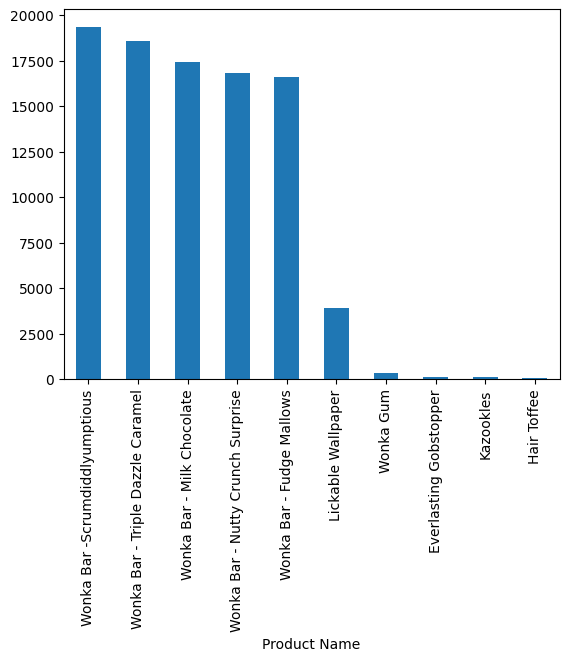

In [16]:
top_products = df.groupby("Product Name")["Gross Profit"].sum().sort_values(ascending=False)

top_products.head(10).plot(kind="bar")
plt.show()